# Why the hybrid beats beam search at equal width (Finding 8e)

At width 100 the hybrid solved 38 cubes that beam search did not, and lost none. The
hybrid tries move bounds from the pattern database's lower bound up to 30, one pruned
beam search per bound, and stops at the first that succeeds. `scripts/hybrid_passes.py`
ran every one of those passes separately on all 1,050 cubes, writing
`runs/adi_d12/hybrid_passes_w100.csv`.

Two questions:

- **Could a single pass, with its bound chosen in advance, match the hybrid?** A single
  pass has to be judged on every cube, not only the 38: a bound that recovers some of
  them can still lose cubes beam search solves. The measure is therefore the change in
  cubes solved compared with beam search, over all 1,050 cubes.
- **How many different bounds solve each of the 38?** If only one or two, the gain comes
  from trying several differently-pruned passes.

The loading cell asserts that the passes rebuild the evaluated hybrid exactly, since
the breakdown means nothing otherwise. Tables are printed before the figure, which is
saved to `figures/why_hybrid_wins.png`.

In [1]:
import csv
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from chart_style import CHART, FIGURES, plot_series, style_axes

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RUN = ROOT / 'runs' / 'adi_d12'
WIDTH = 100
BUDGET = 30
HYBRID_ORANGE = CHART['series'][1]


def per_cube_lengths(solver):
    lengths = {}
    for path in sorted(RUN.glob(f'eval_{solver}_checkpoint_d*_cubes.csv')):
        with open(path) as handle:
            for row in csv.DictReader(handle):
                lengths[(int(row['depth']), int(row['cube']))] = int(row['length'])
    return lengths


beam = per_cube_lengths(f'beam_w{WIDTH}')
hybrid = per_cube_lengths(f'hybrid_w{WIDTH}')

starts = {}
passes = defaultdict(dict)  # (depth, cube) -> {bound: (solved, length)}
with open(RUN / f'hybrid_passes_w{WIDTH}.csv') as handle:
    for row in csv.DictReader(handle):
        key = (int(row['depth']), int(row['cube']))
        starts[key] = int(row['start'])
        passes[key][int(row['bound'])] = (row['solved'] == '1', int(row['length']))

cubes = sorted(starts)


def first_success_length(key):
    if starts[key] == 0:
        return 0
    for bound in sorted(passes[key]):
        solved, length = passes[key][bound]
        if solved:
            return length
    return -1


assert all(first_success_length(key) == hybrid[key] for key in cubes), 'passes do not rebuild the hybrid'

gained = [key for key in cubes if hybrid[key] >= 0 and beam[key] < 0]
print(f'{len(cubes)} cubes; passes rebuild the hybrid on all of them')
print(f'the hybrid solved {len(gained)} cubes that beam search did not')

1050 cubes; passes rebuild the hybrid on all of them
the hybrid solved 38 cubes that beam search did not


In [2]:
ALL_BOUNDS = list(range(8, BUDGET + 1))


def solved_by_pass(key, bound):
    """A pass below the cube's lower bound prunes every child, so it was not run and fails."""
    if starts[key] == 0:
        return True
    return passes[key].get(bound, (False, -1))[0]


# Every cube a single pass solves and beam search does not is also one of the hybrid's
# gains (the hybrid tries that bound), so a pass's net change is recovered minus lost.
recovered = {bound: sum(solved_by_pass(key, bound) for key in gained) for bound in ALL_BOUNDS}
lost = {bound: sum(beam[key] >= 0 and not solved_by_pass(key, bound) for key in cubes) for bound in ALL_BOUNDS}
net = {bound: recovered[bound] - lost[bound] for bound in ALL_BOUNDS}

print('one pass at a fixed move bound B:')
print('bound B'.rjust(24) + ''.join(f'{bound:>5}' for bound in ALL_BOUNDS))
print(f'recovered, of {len(gained)}'.rjust(24) + ''.join(f'{recovered[bound]:>5}' for bound in ALL_BOUNDS))
print('beam-solved cubes lost'.rjust(24) + ''.join(f'{lost[bound]:>5}' for bound in ALL_BOUNDS))
print('net change vs beam'.rjust(24) + ''.join(f'{net[bound]:>+5}' for bound in ALL_BOUNDS))

most_recovered = max(ALL_BOUNDS, key=lambda bound: recovered[bound])
best_net = max(ALL_BOUNDS, key=lambda bound: net[bound])
print()
print(f'most gained cubes recovered by one bound: {recovered[most_recovered]} of {len(gained)} '
      f'(bound {most_recovered}, net {net[most_recovered]:+d})')
print(f'best single pass overall: bound {best_net}, net {net[best_net]:+d} '
      f'({recovered[best_net]} recovered, {lost[best_net]} lost)')

solving_bounds = [sum(solved for solved, _ in passes[key].values()) for key in gained]
distribution = Counter(solving_bounds)
print()
print('how many bounds solve each gained cube:', dict(sorted(distribution.items())))
print(f'median {np.median(solving_bounds):.0f} solving bounds, of a median '
      f'{np.median([len(passes[key]) for key in gained]):.0f} tried')

one pass at a fixed move bound B:
                 bound B    8    9   10   11   12   13   14   15   16   17   18   19   20   21   22   23   24   25   26   27   28   29   30
        recovered, of 38    0    0    4   13   16    5    3    2    2    0    0    2    4    4    6    5    6    9    7    9    9    8   11
  beam-solved cubes lost  192  137   91   50   26   16   15   13   12    9    7    7    7    5    2    2    2    2    1    1    0    0    0
      net change vs beam -192 -137  -87  -37  -10  -11  -12  -11  -10   -9   -7   -5   -3   -1   +4   +3   +4   +7   +6   +8   +9   +8  +11

most gained cubes recovered by one bound: 16 of 38 (bound 12, net -10)
best single pass overall: bound 30, net +11 (11 recovered, 0 lost)

how many bounds solve each gained cube: {1: 13, 2: 9, 3: 5, 4: 3, 5: 3, 6: 1, 9: 1, 11: 1, 12: 1, 14: 1}
median 2 solving bounds, of a median 23 tried


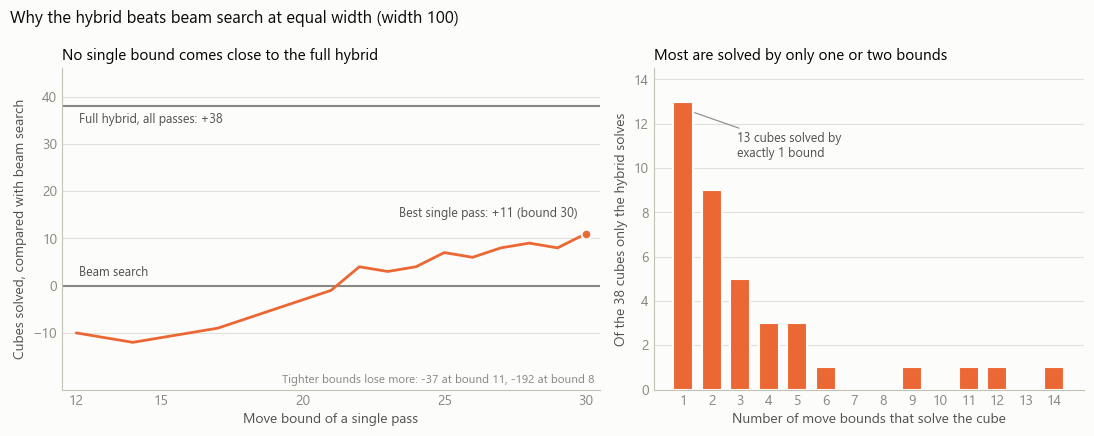

In [3]:
PLOT_FROM = 12  # tighter bounds lose far more; they are noted on the chart and in the table
bounds = [bound for bound in ALL_BOUNDS if bound >= PLOT_FROM]
values = [net[bound] for bound in bounds]

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.4), facecolor=CHART['surface'],
                                  gridspec_kw={'width_ratios': [1.25, 1]})

style_axes(left)
# Beam search's label sits above its line and the full hybrid's below, so neither crosses a gridline.
reference_lines = (
    (0, 'Beam search', (2, 5), 'bottom'),
    (len(gained), f'Full hybrid, all passes: +{len(gained)}', (2, -5), 'top'),
)
for level, text, offset, vertical in reference_lines:
    left.axhline(level, color=CHART['ink_muted'], linewidth=1.5)
    left.annotate(text, xy=(bounds[0], level), xytext=offset, textcoords='offset points',
                  va=vertical, fontsize=9, color=CHART['ink_secondary'])
plot_series(left, bounds, values, HYBRID_ORANGE, markevery=[bounds.index(best_net)])
left.annotate(f'Best single pass: {net[best_net]:+d} (bound {best_net})', xy=(best_net, net[best_net]),
              xytext=(-6, 12), textcoords='offset points', ha='right', fontsize=9,
              color=CHART['ink_secondary'])
tighter = PLOT_FROM - 1
left.annotate(f'Tighter bounds lose more: {net[tighter]:+d} at bound {tighter}, '
              f'{net[ALL_BOUNDS[0]]:+d} at bound {ALL_BOUNDS[0]}',
              xy=(1, 0), xycoords='axes fraction', xytext=(-4, 5), textcoords='offset points',
              ha='right', fontsize=8.5, color=CHART['ink_muted'])
left.set_xlim(bounds[0] - 0.5, bounds[-1] + 0.5)
left.set_ylim(min(values) - 10, len(gained) + 8)
left.set_yticks([-10, 0, 10, 20, 30, 40])
left.set_xticks([12, 15, 20, 25, 30])
left.set_xlabel('Move bound of a single pass')
left.set_ylabel('Cubes solved, compared with beam search')
left.set_title('No single bound comes close to the full hybrid', loc='left', fontsize=11)

style_axes(right)
counts = sorted(distribution.items())
right.bar([count for count, _ in counts], [cubes_with for _, cubes_with in counts], width=0.7,
          color=HYBRID_ORANGE, edgecolor=CHART['surface'], linewidth=1.5)
top_count, top_cubes = max(counts, key=lambda item: item[1])
right.annotate(f'{top_cubes} cubes solved by\nexactly {top_count} bound',
               xy=(top_count + 0.4, top_cubes - 0.5), xytext=(top_count + 1.9, top_cubes - 2),
               va='center', fontsize=9, color=CHART['ink_secondary'],
               arrowprops={'arrowstyle': '-', 'color': CHART['ink_muted'], 'linewidth': 0.8,
                           'shrinkA': 2, 'shrinkB': 0})
right.set_ylim(0, top_cubes + 1.5)
right.set_xticks(range(1, max(solving_bounds) + 1))
right.set_xlabel('Number of move bounds that solve the cube')
right.set_ylabel(f'Of the {len(gained)} cubes only the hybrid solves')
right.set_title('Most are solved by only one or two bounds', loc='left', fontsize=11)

fig.suptitle(f'Why the hybrid beats beam search at equal width (width {WIDTH})', x=0.01, ha='left',
             fontsize=12, color=CHART['ink'])
fig.tight_layout()
fig.savefig(FIGURES / 'why_hybrid_wins.png', dpi=200, facecolor=CHART['surface'], bbox_inches='tight')